# LSTM Time Series Forecasting for Paris Weather Data
This notebook builds a TensorFlow LSTM model to predict hourly temperature using historical Paris weather data from 2020-2025.

## 1. Import Required Libraries
Import TensorFlow, pandas, NumPy, matplotlib, and sklearn preprocessing utilities.

In [38]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [65]:
df.head()

,date,temperature_2m,relative_humidity_2m,precipitation,season,period_of_day,hour_of_day,precipitation_past_3h_sum,relative_humidity_past_1h
0,2020-01-01 00:00:00+00:00,2.35,98.235530,0.0,0,0,0,0.0,98.23553
1,2020-01-01 01:00:00+00:00,1.85,99.643420,0.0,0,0,1,0.0,98.23553
2,2020-01-01 02:00:00+00:00,1.65,100.000000,0.0,0,0,2,0.0,99.64342
3,2020-01-01 03:00:00+00:00,1.95,97.879130,0.0,0,0,3,0.0,100.00000
4,2020-01-01 04:00:00+00:00,1.80,98.933235,0.0,0,0,4,0.0,97.87913


## 2. Load the CSV Dataset
Read data/Paris_2020_2025_hourly.csv into a pandas DataFrame and parse the datetime index.

In [39]:
# Load the dataset
df_raw = pd.read_csv('../data/Paris_2020_2025_hourly.csv')

# Display basic information
print("Dataset shape:", df_raw.shape)
print("\nFirst few rows:")
print(df_raw.head())

Dataset shape: (52608, 4)

First few rows:
                        date  temperature_2m  relative_humidity_2m  \
0  2020-01-01 00:00:00+00:00            2.35             98.235530   
1  2020-01-01 01:00:00+00:00            1.85             99.643420   
2  2020-01-01 02:00:00+00:00            1.65            100.000000   
3  2020-01-01 03:00:00+00:00            1.95             97.879130   
4  2020-01-01 04:00:00+00:00            1.80             98.933235   

   precipitation  
0            0.0  
1            0.0  
2            0.0  
3            0.0  
4            0.0  


## 3. Preprocess the Time Series Data
Select the target column, normalize features, create lagged sequences, and reshape for LSTM input.

In [86]:
# Parse datetime and set as index
df = df_raw.copy()
df['date'] = pd.to_datetime(df['date'])

# Add season for Paris
def get_season(month):
    if month in [12, 1, 2]:
        return 0
    elif month in [3, 4, 5]:
        return 2
    elif month in [6, 7, 8]:
        return 3
    else:
        return 1

df['season'] = df['date'].dt.month.map(get_season)

# Add period of day
def get_period_of_day(hour):
    if 5 <= hour < 12:
        return 1
    elif 12 <= hour < 17:
        return 3
    elif 17 <= hour < 21:
        return 2
    else:
        return 0

df['period_of_day'] = df['date'].dt.hour.map(get_period_of_day)
df['hour_of_day'] = df['date'].dt.hour

# Add sum of precipitation on the past 3 hours
df['precipitation_past_3h_sum'] = df['precipitation'].shift(1).fillna(0).rolling(window=4, min_periods=1).sum()
df['relative_humidity_past_1h'] = df['relative_humidity_2m'].shift(1).fillna(df['relative_humidity_2m'][0])
df['temperature_past_1h'] = df['temperature_2m'].shift(1).fillna(df['relative_humidity_2m'][0])

print("New features added to dataframe:")
print(df.head(10))

New features added to dataframe:
                       date  temperature_2m  relative_humidity_2m  \
0 2020-01-01 00:00:00+00:00            2.35             98.235530   
1 2020-01-01 01:00:00+00:00            1.85             99.643420   
2 2020-01-01 02:00:00+00:00            1.65            100.000000   
3 2020-01-01 03:00:00+00:00            1.95             97.879130   
4 2020-01-01 04:00:00+00:00            1.80             98.933235   
5 2020-01-01 05:00:00+00:00            2.00             99.288860   
6 2020-01-01 06:00:00+00:00            2.10             99.644160   
7 2020-01-01 07:00:00+00:00            2.05             99.644005   
8 2020-01-01 08:00:00+00:00            2.00             99.288860   
9 2020-01-01 09:00:00+00:00            2.20             98.584480   

   precipitation  season  period_of_day  hour_of_day  \
0            0.0       0              0            0   
1            0.0       0              0            1   
2            0.0       0              0

In [ ]:
TARGET_COLUMN = 'temperature_2m'
FEATURES = ['season', 'period_of_day', 'hour_of_day', 'precipitation_past_3h_sum',
       'relative_humidity_past_1h', 'temperature_past_1h']

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[FEATURES + [TARGET_COLUMN]].values)

# Create sequences for LSTM
sequence_length = 24  # Use 24 hours to predict the next hour

def create_sequences(data, seq_length):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length:, 0:-1])
        y.append(data[i + seq_length, -1])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, sequence_length)
print(f"\nSequence shape: X={X.shape}, y={y.shape}")


Sequence shape: X=(52584, 24, 5), y=(52584,)


## 4. Create Train/Test Splits
Split the time series sequences into training and test sets with a temporal boundary.

In [74]:
# Split data into training and testing sets (80-20 split)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

test_size = len(X) - train_size

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training set size: 42067 samples
Testing set size: 10517 samples

Training data shape: X_train=(42067, 24, 5), y_train=(42067,)
Testing data shape: X_test=(10517, 24, 5), y_test=(10517,)


## 5. Build the TensorFlow LSTM Model
Define a Sequential model with LSTM layers, dropout, and a dense output layer using TensorFlow Keras.

In [43]:
# Build the LSTM model
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], len(FEATURES))),
    Dropout(0.2),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=25),
    Dropout(0.2),
    Dense(units=1)
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Display model summary
print("Model Summary:")
model.summary()

Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 24, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 24, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 24, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 25)             │         7,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,026 (152.45 KB)

 Trainable params: 39,026 (152.45 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Checkpoint and early stopping

checkpoint_dir = './checkpoints'
checkpoint_prefix = f'{checkpoint_dir}/model.weights.h5'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True,
    save_best_only=False
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## 6. Train the Model
Compile the model with an optimizer and loss, then fit it on the training data with validation.

In [46]:
# Train the model
print("Training the model...")

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
    callbacks=[checkpoint_callback, early_stopping_callback]
)

print("\nTraining completed!")

Training the model...
Epoch 1/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - loss: 0.0134 - val_loss: 0.0083
Epoch 2/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 0.0090 - val_loss: 0.0072
Epoch 3/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0081 - val_loss: 0.0071
Epoch 4/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0077 - val_loss: 0.0076
Epoch 5/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 0.0075 - val_loss: 0.0072
Epoch 6/50
1315/1315 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - loss: 0.0073 - val_loss: 0.0072

Training completed!


## 7. Evaluate and Plot Predictions
Evaluate model performance on the test set, inverse transform predictions, and plot actual vs predicted values.

In [81]:
scaler.inverse_transform(train_pred)[:,-1]

array([ 4.47786501,  4.44621551,  4.30125086, ..., 11.59413467,
       11.11209494, 10.52861804], shape=(42067,))

In [82]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Recreate dataset for inverse transformation
train_pred = np.concat([X_train[:,23,:], y_train_pred], axis=1)
test_pred = np.concat([X_test[:,23,:], y_test_pred], axis=1)

# Inverse transform predictions and actual values
y_train_actual = df[TARGET_COLUMN].values[sequence_length:train_size + sequence_length]
y_train_pred_rescaled = scaler.inverse_transform(train_pred)[:,-1]
y_test_actual = df[TARGET_COLUMN].values[train_size + sequence_length:train_size + sequence_length + test_size]
y_test_pred_rescaled = scaler.inverse_transform(test_pred)[:,-1]

# Calculate error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
train_mae = mean_absolute_error(y_train_actual, y_train_pred_rescaled)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_rescaled)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_rescaled))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_rescaled))

print("Model Performance Metrics:")
print(f"Training MAE: {train_mae:.4f}")
print(f"Testing MAE: {test_mae:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE: {test_rmse:.4f}")

1315/1315 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Model Performance Metrics:
Training MAE: 3.0905
Testing MAE: 3.0082
Training RMSE: 3.8421
Testing RMSE: 3.7827


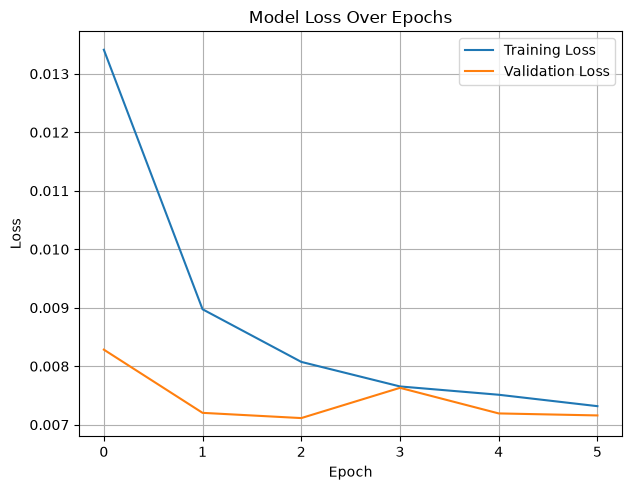


Training history plotted.


In [83]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nTraining history plotted.")

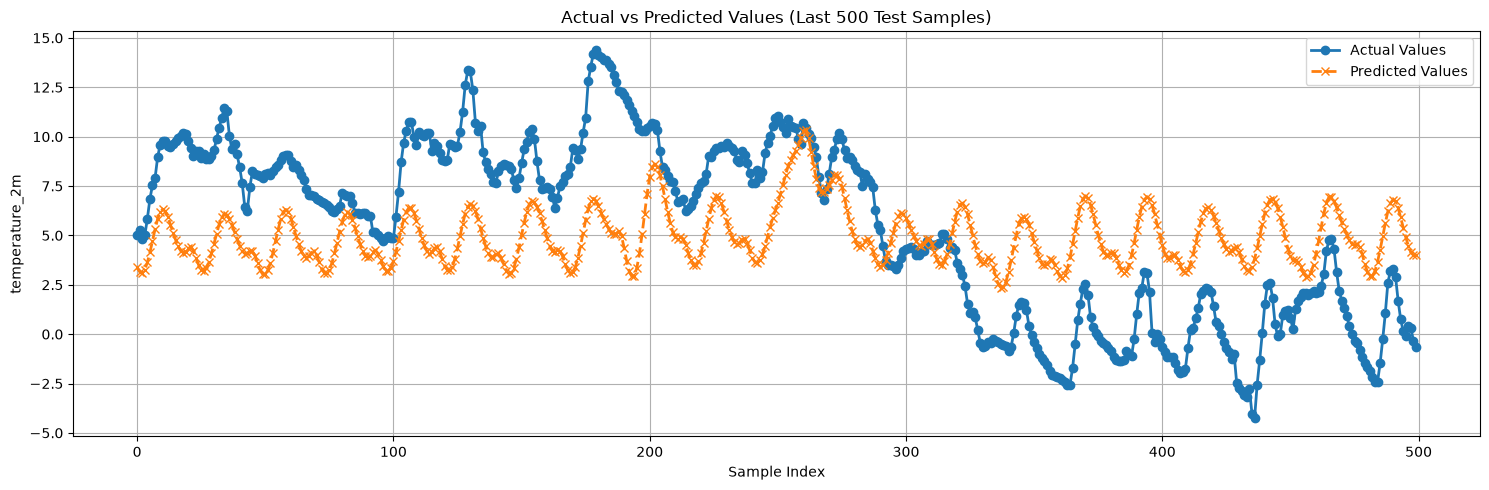


Plotted last 500 test predictions.


In [84]:
# Plot actual vs predicted values for test set
plt.figure(figsize=(15, 5))

# Plot last 500 test predictions for clarity
plot_range = 500
plt.plot(y_test_actual[-plot_range:], label='Actual Values', marker='o', linestyle='-', linewidth=2)
plt.plot(y_test_pred_rescaled[-plot_range:], label='Predicted Values', marker='x', linestyle='--', linewidth=2)
plt.title(f'Actual vs Predicted Values (Last {plot_range} Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel(f'{TARGET_COLUMN}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nPlotted last {plot_range} test predictions.")

In [85]:
# Save the trained model
model.save('lstm_weather_model.h5')
print("Model saved as 'lstm_weather_model.h5'")

Model saved as 'lstm_weather_model.h5'
